In [1]:
import sys
import os
sys.path.insert(0, '..')
os.chdir('..')

## Test set

In [2]:
from rag import dense_retrieve, sparse_retrieve, reciprocal_rank_fusion

test_set = [
    # seasons
    {"q": "Who won the 2021 F1 world championship?",                      "expected": "2021 Formula One World Championship"},
    {"q": "What controversy surrounded the 2021 Abu Dhabi Grand Prix?",   "expected": "2021 Formula One World Championship"},
    {"q": "Who won the 2023 F1 drivers championship?",                    "expected": "2023 Formula One World Championship"},
    {"q": "What happened to Ayrton Senna at the 1994 San Marino GP?",     "expected": "1994 Formula One World Championship"},
    {"q": "Who won the 2016 F1 championship?",                            "expected": "2016 Formula One World Championship"},
    {"q": "What happened between Rosberg and Hamilton in 2016?",          "expected": "2016 Formula One World Championship"},
    {"q": "Who won the 2020 F1 championship?",                            "expected": "2020 Formula One World Championship"},
    {"q": "What made the 2020 season unusual compared to other years?",   "expected": "2020 Formula One World Championship"},
    {"q": "Who won the 2022 drivers championship?",                       "expected": "2022 Formula One World Championship"},
    {"q": "What was the main regulation change in the 2022 season?",      "expected": "2022 Formula One World Championship"},
    {"q": "Who did Michael Schumacher beat in the 2003 championship?",    "expected": "2003 Formula One World Championship"},
    {"q": "How did Hamilton win the 2008 championship on the last lap?",  "expected": "2008 Formula One World Championship"},
    {"q": "Who was Lewis Hamilton's teammate at McLaren in 2008?",        "expected": "2008 Formula One World Championship"},
    # drivers
    {"q": "When did Ayrton Senna die?",                                   "expected": "Ayrton Senna"},
    {"q": "What nationality is Ayrton Senna?",                            "expected": "Ayrton Senna"},
    {"q": "How many world championships did Michael Schumacher win?",     "expected": "Michael Schumacher"},
    {"q": "Which team did Schumacher win his first championship with?",   "expected": "Michael Schumacher"},
    {"q": "How many championships has Lewis Hamilton won?",               "expected": "Lewis Hamilton"},
    {"q": "What team did Fernando Alonso win his championships with?",    "expected": "Fernando Alonso"},
    {"q": "How many championships did Sebastian Vettel win?",             "expected": "Sebastian Vettel"},
    {"q": "What team did Niki Lauda drive for when he had his accident?", "expected": "Niki Lauda"},
    {"q": "What caused Romain Grosjean's crash in Bahrain 2020?",        "expected": "Romain Grosjean"},
    {"q": "What team does Lando Norris drive for?",                       "expected": "Lando Norris"},
    {"q": "How many championships did Jenson Button win?",                "expected": "Jenson Button"},
    {"q": "Which team did Jenson Button win the championship with?",      "expected": "Jenson Button"},
    {"q": "What is Kimi Räikkönen's nickname?",                           "expected": "Kimi Räikkönen"},
    {"q": "Which year did Kimi Räikkönen win the world championship?",    "expected": "Kimi Räikkönen"},
    {"q": "How many championships did Damon Hill win?",                   "expected": "Damon Hill"},
    {"q": "Who did Damon Hill lose the 1994 championship to?",            "expected": "Damon Hill"},
    {"q": "How many championships did Mika Häkkinen win and with which team?", "expected": "Mika Häkkinen"},
    {"q": "What year did Nigel Mansell win the F1 world championship?",   "expected": "Nigel Mansell"},
    {"q": "What team did Rubens Barrichello race for during his best years?", "expected": "Rubens Barrichello"},
    {"q": "What team does George Russell drive for?",                     "expected": "George Russell (racing driver)"},
    {"q": "What nationality is Carlos Sainz Jr.?",                        "expected": "Carlos Sainz Jr."},
    # teams
    {"q": "When was Red Bull Racing founded?",                            "expected": "Red Bull Racing"},
    {"q": "How many constructors championships has Ferrari won?",         "expected": "Scuderia Ferrari"},
    {"q": "Which team dominated the hybrid era from 2014?",               "expected": "Mercedes AMG Petronas Formula One Team"},
    {"q": "What is McLaren's most successful period in F1?",              "expected": "McLaren"},
    {"q": "What was the Aston Martin F1 team called before it rebranded?","expected": "Aston Martin F1 Team"},
    {"q": "Which engine does the Haas F1 team use?",                      "expected": "Haas F1 Team"},
    {"q": "What is Williams Racing's most successful era?",               "expected": "Williams Racing"},
    # circuits
    {"q": "Which circuit hosts the Monaco Grand Prix?",                   "expected": "Circuit de Monaco"},
    {"q": "Where is the British Grand Prix held?",                        "expected": "Silverstone Circuit"},
    {"q": "What is the famous corner at Spa called?",                     "expected": "Circuit de Spa-Francorchamps"},
    {"q": "What makes the Suzuka circuit layout unusual?",                "expected": "Suzuka Circuit"},
    {"q": "Which country hosts the Bahrain Grand Prix?",                  "expected": "Bahrain International Circuit"},
    {"q": "Where in the USA is the Circuit of the Americas located?",     "expected": "Circuit of the Americas"},
    {"q": "What is the Interlagos circuit officially called?",            "expected": "Autódromo José Carlos Pace"},
    {"q": "What is Monza known for in terms of track characteristics?",   "expected": "Autodromo Nazionale Monza"},
    # topics
    {"q": "What is DRS and when can drivers use it?",                     "expected": "DRS (Formula One)"},
    {"q": "What is porpoising and why was it a problem in 2022?",         "expected": "Porpoising in Formula One"},
    {"q": "What does the safety car do in Formula One?",                  "expected": "Safety car (Formula One)"},
    {"q": "What are the different tyre compounds used in F1?",            "expected": "Formula One tyres"},
    {"q": "What is KERS and how does it work in Formula One?",            "expected": "Kinetic energy recovery system"},
    {"q": "How long does a typical F1 pit stop take?",                    "expected": "Formula One pit stop"},
    # more drivers
    {"q": "What is Max Verstappen's nationality?",                        "expected": "Max Verstappen"},
    {"q": "Which team does Charles Leclerc race for?",                    "expected": "Charles Leclerc"},
    {"q": "How many world championships did Alain Prost win?",            "expected": "Alain Prost"},
    {"q": "In what year did Niki Lauda have his accident at the Nurburgring?", "expected": "Niki Lauda"},
    # more seasons
    {"q": "Which constructor won the 2023 F1 championship?",              "expected": "2023 Formula One World Championship"},
    {"q": "Who was Damon Hill's main rival in the 1994 season?",          "expected": "1994 Formula One World Championship"},
    # more circuits and topics
    {"q": "What is the Autodromo Nazionale Monza famous for?",            "expected": "Autodromo Nazionale Monza"},
    {"q": "What power unit configuration do modern F1 cars use?", "expected": "Formula One car"},

    # more seasons
    {"q": "Who was runner up in the 2021 championship?", "expected": "2021 Formula One World Championship"},
    {"q": "What team did the 2021 champion race for?", "expected": "2021 Formula One World Championship"},
    {"q": "Who won the most races in the 2023 season?", "expected": "2023 Formula One World Championship"},
    {"q": "What happened on the last lap of the 2008 Brazilian GP?", "expected": "2008 Formula One World Championship"},
    {"q": "Who finished second in the 2008 championship?", "expected": "2008 Formula One World Championship"},
    {"q": "How did Schumacher win the 1994 championship controversially?", "expected": "1994 Formula One World Championship"},
    {"q": "What year did Hamilton first win the world championship?", "expected": "2008 Formula One World Championship"},
    {"q": "What made the 2020 season different from all other seasons?", "expected": "2020 Formula One World Championship"},
    {"q": "Which driver dominated the start of the 2022 season?", "expected": "2022 Formula One World Championship"},
    {"q": "How many races did Verstappen win in 2022?", "expected": "2022 Formula One World Championship"},
    {"q": "What is the 2012 season famous for in terms of different race winners?", "expected": "2012 Formula One World Championship"},
    {"q": "Who won the 2012 championship on the last lap in Brazil?", "expected": "2012 Formula One World Championship"},
    {"q": "What happened at the 2016 Spanish GP between the two Mercedes drivers?", "expected": "2016 Formula One World Championship"},
    {"q": "How close was the 2003 championship points gap?", "expected": "2003 Formula One World Championship"},
    {"q": "What happened in the 2020 Bahrain GP involving Grosjean?", "expected": "2020 Formula One World Championship"},
    {"q": "Who won the constructors title in 2021?", "expected": "2021 Formula One World Championship"},
    {"q": "Which season saw the return of ground effect cars?", "expected": "2022 Formula One World Championship"},
    {"q": "Who did Verstappen beat to win the 2021 title?", "expected": "2021 Formula One World Championship"},
    {"q": "How many different winners were there in the 2012 season?", "expected": "2012 Formula One World Championship"},
    {"q": "What team won the 2003 constructors championship?", "expected": "2003 Formula One World Championship"},

    # more drivers
    {"q": "What year did Hamilton move from McLaren to Mercedes?", "expected": "Lewis Hamilton"},
    {"q": "How old was Verstappen when he made his F1 debut?", "expected": "Max Verstappen"},
    {"q": "What team did Alonso come back to F1 with in 2021?", "expected": "Fernando Alonso"},
    {"q": "Why did Sebastian Vettel retire from F1?", "expected": "Sebastian Vettel"},
    {"q": "What two constructors did Niki Lauda win championships with?", "expected": "Niki Lauda"},
    {"q": "What was Alain Prost's nickname?", "expected": "Alain Prost"},
    {"q": "What happened between Senna and Prost at the 1989 Japanese GP?", "expected": "Ayrton Senna"},
    {"q": "What year did Schumacher come out of retirement?", "expected": "Michael Schumacher"},
    {"q": "How many pole positions does Hamilton have in his career?", "expected": "Lewis Hamilton"},
    {"q": "Where is Lando Norris from?", "expected": "Lando Norris"},
    {"q": "Did Romain Grosjean ever win an F1 race?", "expected": "Romain Grosjean"},
    {"q": "What year did Jenson Button win the world championship?", "expected": "Jenson Button"},
    {"q": "Which team gave Jenson Button his championship-winning car?", "expected": "Jenson Button"},
    {"q": "What is Kimi Räikkönen known for saying to his engineer during races?", "expected": "Kimi Räikkönen"},
    {"q": "What team did Kimi Räikkönen win the 2007 championship with?", "expected": "Kimi Räikkönen"},
    {"q": "Who is Damon Hill's father and what is he famous for in F1?", "expected": "Damon Hill"},
    {"q": "How did Damon Hill lose the 1994 championship to Schumacher?", "expected": "Damon Hill"},
    {"q": "What team did Mika Häkkinen race for during his entire F1 career?", "expected": "Mika Häkkinen"},
    {"q": "What year did Häkkinen win his second championship?", "expected": "Mika Häkkinen"},
    {"q": "What is Nigel Mansell's nickname?", "expected": "Nigel Mansell"},
    {"q": "How many races did Mansell win in his 1992 championship season?", "expected": "Nigel Mansell"},
    {"q": "How long was Rubens Barrichello Michael Schumacher's teammate at Ferrari?", "expected": "Rubens Barrichello"},
    {"q": "Did Rubens Barrichello ever win an F1 world championship?", "expected": "Rubens Barrichello"},
    {"q": "What team did George Russell drive for before joining Mercedes?", "expected": "George Russell (racing driver)"},
    {"q": "Where is Carlos Sainz Jr. from?", "expected": "Carlos Sainz Jr."},
    {"q": "Who is Carlos Sainz Jr.'s father?", "expected": "Carlos Sainz Jr."},
    {"q": "What nationality is Oscar Piastri?", "expected": "Oscar Piastri"},
    {"q": "What team does Oscar Piastri race for?", "expected": "Oscar Piastri"},
    {"q": "What team did Valtteri Bottas join after leaving Mercedes?", "expected": "Valtteri Bottas"},
    {"q": "How many years was Bottas Hamilton's teammate at Mercedes?", "expected": "Valtteri Bottas"},
    {"q": "What team did Niki Lauda move to after Ferrari?", "expected": "Niki Lauda"},
    {"q": "How many career race wins did Alain Prost have?", "expected": "Alain Prost"},
    {"q": "What happened between Senna and Prost at Suzuka 1990?", "expected": "Ayrton Senna"},
    {"q": "What permanent car number does Verstappen use?", "expected": "Max Verstappen"},
    {"q": "What team was Leclerc driving for before he joined Ferrari?", "expected": "Charles Leclerc"},

    # more teams
    {"q": "Is Alpine F1 the same organisation as Renault F1?", "expected": "Alpine F1 Team"},
    {"q": "Who founded Haas F1 team?", "expected": "Haas F1 Team"},
    {"q": "What happened to the Renault F1 team after their championship era?", "expected": "Renault in Formula One"},
    {"q": "What team did Alonso win his two championships with?", "expected": "Renault in Formula One"},
    {"q": "Who designed the dominant Red Bull cars from 2010 to 2013?", "expected": "Red Bull Racing"},
    {"q": "How many drivers championships has McLaren's cars produced?", "expected": "McLaren"},
    {"q": "What is the most successful constructor in F1 history?", "expected": "Formula One World Constructors Championship"},
    {"q": "When was the constructors championship first awarded?", "expected": "Formula One World Constructors Championship"},
    {"q": "What team is associated with Jim Clark and the early Lotus era?", "expected": "Lotus Cars"},
    {"q": "When did Williams Racing last win a race?", "expected": "Williams Racing"},
    {"q": "What was Mercedes called before they entered F1 as a works team?", "expected": "Mercedes AMG Petronas Formula One Team"},
    {"q": "How many constructors championships has Red Bull won?", "expected": "Red Bull Racing"},
    {"q": "What engine does Haas use?", "expected": "Haas F1 Team"},
    {"q": "What is Lotus Cars' most successful period in F1?", "expected": "Lotus Cars"},

    # more circuits
    {"q": "How many corners does the Monaco circuit have?", "expected": "Circuit de Monaco"},
    {"q": "What is the elevation change at the Spa circuit?", "expected": "Circuit de Spa-Francorchamps"},
    {"q": "How long is the Silverstone circuit?", "expected": "Silverstone Circuit"},
    {"q": "Why is the Hungaroring considered bad for overtaking?", "expected": "Hungaroring"},
    {"q": "Where is the Hungaroring located?", "expected": "Hungaroring"},
    {"q": "Who is the Circuit Gilles Villeneuve named after?", "expected": "Circuit Gilles Villeneuve"},
    {"q": "In which city is the Canadian Grand Prix held?", "expected": "Circuit Gilles Villeneuve"},
    {"q": "When did Bahrain first join the F1 calendar?", "expected": "Bahrain International Circuit"},
    {"q": "Why is Interlagos significant for F1 championship finales?", "expected": "Autódromo José Carlos Pace"},
    {"q": "What is the name of the main straight at Monza?", "expected": "Autodromo Nazionale Monza"},
    {"q": "What happened at Suzuka in 2000 that decided the championship?", "expected": "Suzuka Circuit"},
    {"q": "What is the famous figure-8 feature of Suzuka?", "expected": "Suzuka Circuit"},
    {"q": "Why is COTA's turn 1 considered one of the best in modern F1?", "expected": "Circuit of the Americas"},
    {"q": "What is the Raidillon at Spa?", "expected": "Circuit de Spa-Francorchamps"},
    {"q": "How long is the Spa circuit in km?", "expected": "Circuit de Spa-Francorchamps"},

    # more topics
    {"q": "What is the difference between soft and hard tyres in F1?", "expected": "Formula One tyres"},
    {"q": "Why do F1 drivers have to use two different tyre compounds in a dry race?", "expected": "Formula One tyres"},
    {"q": "What does tyre deg mean in F1?", "expected": "Formula One tyres"},
    {"q": "How does KERS store and release energy in a Formula One car?", "expected": "Kinetic energy recovery system"},
    {"q": "What year was KERS first used in Formula One?", "expected": "Kinetic energy recovery system"},
    {"q": "What is ground effect and why was it banned in the early 80s?", "expected": "Ground effect (cars)"},
    {"q": "When did ground effect cars return to Formula One?", "expected": "Ground effect (cars)"},
    {"q": "How many people are typically involved in a modern F1 pit stop?", "expected": "Formula One pit stop"},
    {"q": "What is an undercut strategy in F1?", "expected": "Formula One pit stop"},
    {"q": "What is an overcut strategy in F1?", "expected": "Formula One pit stop"},
    {"q": "What does parc fermé mean in Formula One?", "expected": "Formula One regulations"},
    {"q": "How many points does an F1 race winner get?", "expected": "Formula One regulations"},
    {"q": "What is a virtual safety car in Formula One?", "expected": "Safety car (Formula One)"},
    {"q": "What happens to the tyres you must use in wet conditions?", "expected": "Formula One tyres"},
    {"q": "How many engines is an F1 driver allowed per season?", "expected": "Formula One regulations"},
]

print(f"test set: {len(test_set)} questions")

test set: 162 questions


## Hit rate naive vs hybrid

In [3]:
import pandas as pd
def hit_rate_naive(test_set, k):
    hits = sum(
        any(c["source"] == item["expected"] for c in dense_retrieve(item["q"], k))
        for item in test_set
    )
    return hits / len(test_set)
def hit_rate_hybrid(test_set, k):
    hits = 0
    for item in test_set:
        fused = reciprocal_rank_fusion(
            dense_retrieve(item["q"], 20),
            sparse_retrieve(item["q"], 20)
        )[:k]
        if any(c["source"] == item["expected"] for c in fused):
            hits += 1
    return hits / len(test_set)
rows = []
for k in [1, 3, 5, 8]:
    rows.append({
        "k": k,
        "naive":  round(hit_rate_naive(test_set, k), 2),
        "hybrid": round(hit_rate_hybrid(test_set, k), 2)
    })
print(pd.DataFrame(rows).to_string(index=False))


 k  naive  hybrid
 1   0.31    0.41
 3   0.44    0.72
 5   0.52    0.81
 8   0.60    0.88


In [4]:
## Hit rate by category (k=5, hybrid)

In [5]:
category_map = {
    "seasons":  ["Formula One World Championship"],
    "drivers":  ["Senna", "Hamilton", "Schumacher", "Alonso", "Vettel", "Lauda", "Prost",
                 "Grosjean", "Norris", "Button", "Räikkönen", "Hill", "Häkkinen",
                 "Mansell", "Barrichello", "Russell", "Sainz", "Verstappen", "Leclerc", "Bottas"],
    "teams":    ["Red Bull Racing", "Ferrari", "Mercedes", "McLaren", "Williams", "Aston Martin", "Haas", "Alpine"],
    "circuits": ["Monaco", "Silverstone", "Monza", "Spa", "Suzuka", "Bahrain", "Americas", "Pace", "Hungaroring"],
    "topics":   ["DRS", "Porpoising", "Safety car", "tyres", "KERS", "pit stop", "car", "regulations"],
}

def get_category(expected: str) -> str:
    for cat, keywords in category_map.items():
        if any(kw.lower() in expected.lower() for kw in keywords):
            return cat
    return "other"

k = 5
cat_results = {}
for item in test_set:
    cat = get_category(item["expected"])
    fused = reciprocal_rank_fusion(
        dense_retrieve(item["q"], 20),
        sparse_retrieve(item["q"], 20)
    )[:k]
    hit = any(c["source"] == item["expected"] for c in fused)
    if cat not in cat_results:
        cat_results[cat] = {"hits": 0, "total": 0}
    cat_results[cat]["hits"]  += int(hit)
    cat_results[cat]["total"] += 1

print(f"{'Category':<12} {'Hit Rate':>10}  {'Hits':>6}/{' Total'}")
print("-" * 38)
for cat, r in sorted(cat_results.items()):
    rate = r["hits"] / r["total"]
    print(f"{cat:<12} {rate:>10.2f}  {r['hits']:>5}/{r['total']}")

Category       Hit Rate    Hits/ Total
--------------------------------------
circuits           0.77     17/22
drivers            0.86     50/58
other              0.56      5/9
seasons            0.91     32/35
teams              0.67     10/15
topics             0.74     17/23


## Plot it

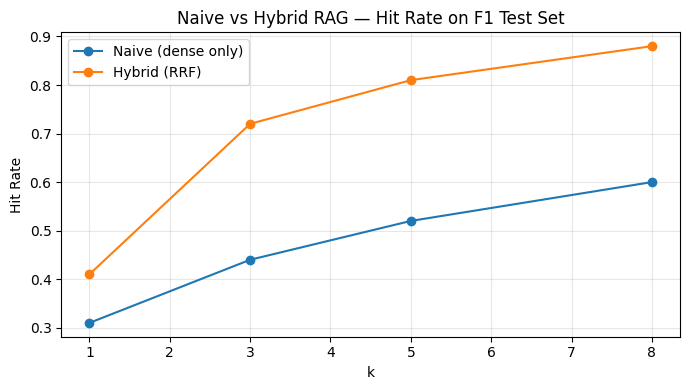

In [6]:
import matplotlib.pyplot as plt
df = pd.DataFrame(rows)
plt.figure(figsize=(7, 4))
plt.plot(df["k"], df["naive"],  marker="o", label="Naive (dense only)")
plt.plot(df["k"], df["hybrid"], marker="o", label="Hybrid (RRF)")
plt.xlabel("k")
plt.ylabel("Hit Rate")
plt.title("Naive vs Hybrid RAG — Hit Rate on F1 Test Set")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("hit_rate.png", dpi=150)
plt.savefig("../hit_rate.png", dpi=150)
plt.show()

## Failure Cases 

In [7]:
from rag import ask_hybrid
failures = [
    "Who had more podiums in total, Senna or Prost?",
    "What lap did the Safety Car come out in the 2021 Abu Dhabi finale?",
]
for q in failures:
    r = ask_hybrid(q)
    print(f"Q: {q}")
    print(f"A: {r['answer'][:300]}")
    print(f"Sources: {[c['source'] for c in r['sources']]}\n")

Q: Who had more podiums in total, Senna or Prost?
A: This question cannot be answered from the provided context, as the context only mentions Ayrton Senna and does not mention Prost.
Sources: ['Michael Schumacher', 'Rubens Barrichello', 'Ayrton Senna', '2023 Formula One World Championship', 'Williams Racing', 'Kimi Räikkönen']

Q: What lap did the Safety Car come out in the 2021 Abu Dhabi finale?
A: The text does not provide the lap number that the Safety Car came out in the 2021 Abu Dhabi finale.
Sources: ['2021 Formula One World Championship', '2021 Formula One World Championship', 'Circuit of the Americas', '2022 Formula One World Championship', '2020 Formula One World Championship', 'Mercedes AMG Petronas Formula One Team']

